Device: cuda
Train shape: (269, 4) Test shape: (264, 3) Sample: (264, 2)
Sizes -> Train: 215 Val: 27 Internal Test: 27
Epoch 1/20 | Train loss: 0.6790, acc: 0.6000 | Val loss: 0.6397, acc: 0.8148
Epoch 2/20 | Train loss: 0.6233, acc: 0.7860 | Val loss: 0.5835, acc: 0.8148
Epoch 3/20 | Train loss: 0.5286, acc: 0.8419 | Val loss: 0.4961, acc: 0.8148
Epoch 4/20 | Train loss: 0.4120, acc: 0.8977 | Val loss: 0.4005, acc: 0.8148
Epoch 5/20 | Train loss: 0.3063, acc: 0.9023 | Val loss: 0.3418, acc: 0.8148
Epoch 6/20 | Train loss: 0.2318, acc: 0.9256 | Val loss: 0.3025, acc: 0.8519
Epoch 7/20 | Train loss: 0.1822, acc: 0.9535 | Val loss: 0.2932, acc: 0.8519
Epoch 8/20 | Train loss: 0.1351, acc: 0.9814 | Val loss: 0.3460, acc: 0.8148
Epoch 9/20 | Train loss: 0.0974, acc: 0.9767 | Val loss: 0.1772, acc: 0.9259
Epoch 10/20 | Train loss: 0.0831, acc: 0.9814 | Val loss: 0.2750, acc: 0.8519
Epoch 11/20 | Train loss: 0.0607, acc: 0.9953 | Val loss: 0.1409, acc: 0.9630
Epoch 12/20 | Train loss: 0.0461

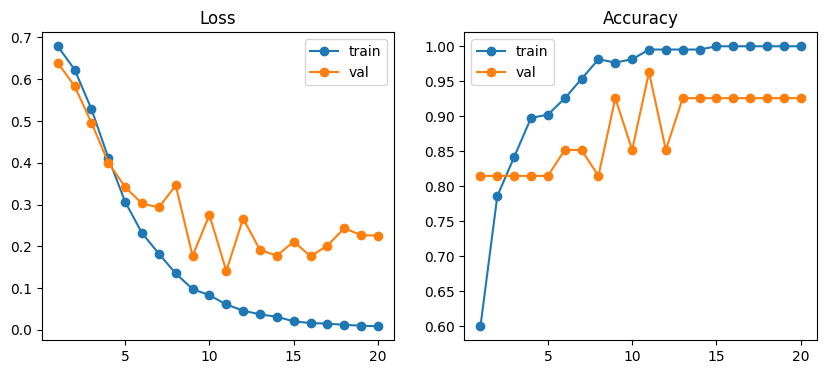

Prediction count: 264 Test rows: 264
Saved submission.csv with shape: (264, 2)
                                id  is_cheating
0  form_r_AAABmJpaBSZniRCnvHlBs66K            1
1    form_r_JiL6ylwnijP66wTCo52XSP            1
2  form_r_AAABmLN7KCDw89RJl3RORa5n            0
3  form_r_AAABmN2ij3UoaExF4jxFcZ_7            0
4  form_r_AAABmJYbGzEuL3gArMVHMZ1P            0


In [2]:
# ======= Mercor AI Detection - Corrected End-to-end Script =======
# Paste this entire block into your notebook cell and run.

import os
import re
import numpy as np
import pandas as pd
import nltk
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ===== CONFIG =====
LOCAL = True   # set False if running on Kaggle (then use Kaggle paths)
if LOCAL:
    BASE = r"D:\Work_Station\DeeplearningBasics\data\mercor_ai"
else:
    BASE = "/kaggle/input/mercor-ai-detection"   # adjust if different mounted path
TRAIN_PATH = os.path.join(BASE, "train.csv")
TEST_PATH = os.path.join(BASE, "test.csv")
SAMPLE_PATH = os.path.join(BASE, "sample_submission.csv")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

# ===== NLTK =====
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ===== Load data =====
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape, "Sample:", sample_submission.shape)

# ===== Simple cleaning function =====
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine and clean
train_df["combined_text"] = train_df["topic"].astype(str) + " " + train_df["answer"].astype(str)
train_df["combined_text"] = train_df["combined_text"].apply(clean_text)

test_df["combined_text"] = test_df["topic"].astype(str) + " " + test_df["answer"].astype(str)
test_df["combined_text"] = test_df["combined_text"].apply(clean_text)

# ===== Train/Val/Test split from train.csv (internal) =====
X = train_df["combined_text"].values
y = train_df["is_cheating"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test_internal, y_val, y_test_internal = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Sizes -> Train:", len(X_train), "Val:", len(X_val), "Internal Test:", len(X_test_internal))

# ===== Tokenizer & model load =====
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
backbone = AutoModel.from_pretrained("distilbert-base-uncased")

# ===== Dataset classes =====
class TrainDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors='pt'
        )
        inputs = {k: v.squeeze(0) for k, v in encoded.items()}
        return inputs, self.labels[idx]

class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors='pt'
        )
        return {k: v.squeeze(0) for k, v in encoded.items()}

# ===== Create dataset & dataloaders =====
BATCH_SIZE = 16
train_ds = TrainDataset(X_train, y_train, tokenizer, max_len=128)
val_ds = TrainDataset(X_val, y_val, tokenizer, max_len=128)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ===== Model definition (no Sigmoid, return logits) =====
class MyModel(nn.Module):
    def __init__(self, bert):
        super(MyModel, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)   # outputs raw logit
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        pooled = outputs[0][:, 0, :]   # CLS token
        x = self.linear1(pooled)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x.view(-1)   # flatten to shape (batch,)

# ===== Freeze base, then unfreeze last 2 layers (recommended) =====
for param in backbone.parameters():
    param.requires_grad = False

# Unfreeze last two transformer layers for fine-tuning
for name, param in backbone.named_parameters():
    if "transformer.layer.4" in name or "transformer.layer.5" in name:
        param.requires_grad = True

model = MyModel(backbone).to(device)

# ===== Loss & Optimizer =====
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=2e-5)   # lower LR for fine-tuning

# ===== Training loop (apply sigmoid for acc calculation) =====
EPOCHS = 20
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    for batch in train_loader:
        inputs, labels = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)

        logits = model(inputs["input_ids"], inputs["attention_mask"])
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        running_correct += (preds == labels.long()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)

            logits = model(inputs["input_ids"], inputs["attention_mask"])
            loss = criterion(logits, labels)
            val_loss += loss.item() * labels.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            val_correct += (preds == labels.long()).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

# ===== (Optional) plot metrics =====
try:
    import matplotlib.pyplot as plt
    epochs = range(1, EPOCHS+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], marker='o', label='train')
    plt.plot(epochs, history["val_loss"], marker='o', label='val')
    plt.title("Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], marker='o', label='train')
    plt.plot(epochs, history["val_acc"], marker='o', label='val')
    plt.title("Accuracy")
    plt.legend()
    plt.show()
except Exception as e:
    print("Plot error:", e)

# ===== Inference on competition test set =====
test_texts = test_df["combined_text"].tolist()
test_dataset = TestDataset(test_texts, tokenizer, max_len=128)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(batch["input_ids"], batch["attention_mask"])
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int).tolist()
        predictions.extend(preds)

# ===== Safety checks & prepare submission =====
print("Prediction count:", len(predictions), "Test rows:", len(test_df))
assert len(predictions) == len(test_df), "Prediction count mismatch!"

# Build submission dataframe exactly as sample_submission expects
# If sample_submission has 'id' and 'is_cheating', preserve id order
if "id" in sample_submission.columns:
    submission = pd.DataFrame({
        "id": test_df["id"],
        "is_cheating": [int(p) for p in predictions]
    })
else:
    # sample_submission might just have is_cheating; adapt accordingly
    submission = pd.DataFrame({
        "is_cheating": [int(p) for p in predictions]
    })

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv with shape:", submission.shape)
print(submission.head())

# ===== Done =====
